In [59]:
import pandas as pd
import re
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# read in TikTok user data and trends data
datasets = {
    #rugby
    "Ramsey": pd.read_csv("data/ariana.ramsey.csv"),
    "Maher": pd.read_csv("data/ilonamaher.csv"),
    
    #syncro
    "Ramirez": pd.read_csv("data/daniellaaramirezzz.csv"),
    "Hunter": pd.read_csv("data/call.me.kekes.csv"),
    
    #snowboard
    "Kim": pd.read_csv("data/chloekim.csv"),
    "Mastro": pd.read_csv("data/maddie_mastro.csv"),

    #skeleton / bobsled
    "Humphries": pd.read_csv("data/kailsarmbruster.csv"),
    "Ro": pd.read_csv("data/mystiquero.csv")
}

# read in google trends data
rugbyTrends = pd.read_csv("data/rugbyTrends.csv")
syncroTrends = pd.read_csv("data/syncroTrends.csv")
sbTrends = pd.read_csv("data/snowboardTrends.csv")
skelTrends = pd.read_csv("data/skelBobsledTrends.csv")

# add total row to each trends dataset
rugbyTrends["Total"] = rugbyTrends.drop(columns=["Time"]).sum(axis=1)
syncroTrends["Total"] = syncroTrends.drop(columns=["Time"]).sum(axis=1)
sbTrends["Total"] = sbTrends.drop(columns=["Time"]).sum(axis=1)
skelTrends["Total"] = skelTrends.drop(columns=["Time"]).sum(axis=1)


print("done")

done


In [108]:
# DOES NOT WORK -> Used https://trevorfox.com/tiktok-video-date-extractor/ instead to get the post dates
# could not get dates for "photo" type posts -> manually entered them

# gets TikTok ID from Post URL
# def extract_tiktok_id(url):
#     match = re.search(r'/video/(\d+)', str(url))
#     return int(match.group(1)) if match else None

# # calculates post datetime from ID
# def tiktok_id_to_datetime(tiktok_id):
#     if pd.isna(tiktok_id):
#         return None
#     try:
#         tiktok_id = int(tiktok_id)  # ensure it's an integer
#         tiktok_epoch = 0  # This epoch seems correct for modern TikTok IDs
#         timestamp_ms = ((tiktok_id >> 22)) + tiktok_epoch
#         return datetime.fromtimestamp(timestamp_ms / 1000, tz=timezone.utc)
#     except Exception:
#         return None

# # Loop to apply for all tiktok accounts for all tiktok accounts
# for name, df in datasets.items():
#     df["TikTok ID"] = df["Post URL"].apply(extract_tiktok_id)
#     df["Post Date"] = df["TikTok ID"].apply(tiktok_id_to_datetime)
#     df.drop(columns=["TikTok ID"], inplace=True)

#print(datasets["Ro"].head)
#print(datasets["Ro"].tail)

# nest_asyncio.apply()

# api = TikTokApi()

# for name, df in datasets.items():
#     post_dates = []
#     for url in df["Post URL"]:
#         video_id = extract_tiktok_id(url)
#         try:
#             video = api.video(id=video_id)
#             data = video.info()  # synchronous
#             post_dates.append(pd.to_datetime(data["createTime"], unit='s'))
#         except Exception as e:
#             post_dates.append(None)
#             print(f"Failed for {url}: {e}")
#     df["Post Date"] = post_dates

<bound method NDFrame.head of                                            Description  Views  Likes  \
0    A girl that takes recovery seriously, knows wh...    620     87   
1    My Olympic Exit strategy.. bring in the hounds...    439     50   
2    1 month of hair growth ✨ #hairgrowth #blasian ...    459     50   
3    I bought myself a 🌹  #treatyourself #foreverfl...    419     57   
4    PMS special feature this month 🍈🍈 #pms #auntfl...    306     23   
..                                                 ...    ...    ...   
653  Looking for a VA please DM and/or check bio fo...   1576     60   
654  #fml #bruises #fakebod #screamingcrying #laugh...   1085     16   
655  When coach spikes up #masterandapprentice #ske...   6262     92   
656  Preparation is 🔑 #floro #skeletonsport #skelet...   1680     16   
657  #airlines #checkedbag #oversizedluggage #trave...   6901    304   

     Comments  Shares  Bookmarks  \
0           5       1          3   
1           6       1          0 

In [65]:
# creating pairs by sport
pairs = [
    ("Ramsey", "Maher", "Rugby", "Summer"),
    ("Ramirez", "Hunter", "Syncro", "Summer"),
    ("Kim", "Mastro", "Snowboarding", "Winter"),
    ("Humphries", "Ro", "SkeletonBobsled", "Winter")
]

datasets_trends = {
    "Rugby": rugbyTrends,
    "Syncro": syncroTrends,
    "Snowboarding": sbTrends,
    "SkeletonBobsled": skelTrends
}

In [61]:
#exploratory analysis for athletes accounts

#individual athletes summary stats
results_ind = {}
for name, df in datasets.items():
    df = df.copy()
    df["Post Date"] = pd.to_datetime(df["Post Date"], errors="coerce")
    df = df.sort_values("Post Date")
    stats = df[["Views", "Likes", "Comments", "Shares", "Bookmarks"]].agg(
        ["mean", "median", "std", "min", "max"]
    )
    time_diffs = df["Post Date"].diff().dropna().dt.total_seconds() / (60 * 60 * 24)  # in days
    time_stats = {
        "avg_days_between_posts": time_diffs.mean(),
        "median_days_between_posts": time_diffs.median()
    }
    results_ind[name] = {
        "engagement_stats": stats,
        "time_between_posts": time_stats
    }
print(results_ind)

#summary stats by sports
results_pairs = {}
for name1, name2, label in pairs:
    df1 = datasets[name1].copy()
    df2 = datasets[name2].copy()
    df = pd.concat([df1, df2], ignore_index=True)
    df["Post Date"] = pd.to_datetime(df["Post Date"], errors="coerce")
    df = df.sort_values("Post Date")
    stats = df[["Views", "Likes", "Comments", "Shares", "Bookmarks"]].agg(
        ["mean", "median", "std", "min", "max"]
    )
    time_diffs = df["Post Date"].diff().dropna().dt.total_seconds() / (60 * 60 * 24)
    time_stats = {
        "avg_days_between_posts": time_diffs.mean(),
        "median_days_between_posts": time_diffs.median()
    }
    results_pairs[label] = {
        "engagement_stats": stats,
        "time_between_posts": time_stats
    }
print(results_pairs)


{'Ramsey': {'engagement_stats':                Views          Likes     Comments       Shares    Bookmarks
mean    1.223481e+04    1192.166667    16.866667    26.994444    22.640741
median  9.790000e+02      83.000000     2.500000     0.000000     1.000000
std     7.756418e+04   10732.590848    76.829720   317.795564   177.266004
min     8.900000e+01       6.000000     0.000000     0.000000     0.000000
max     1.600000e+06  235100.000000  1008.000000  6885.000000  3731.000000, 'time_between_posts': {'avg_days_between_posts': np.float64(4.017774685631828), 'median_days_between_posts': np.float64(1.0618055555555554)}}, 'Maher': {'engagement_stats':                Views         Likes      Comments         Shares     Bookmarks
mean    8.346054e+05  8.771006e+04    356.055695    1469.680538   1142.497497
median  1.314500e+05  1.275000e+04     77.000000      57.000000     92.000000
std     2.212731e+06  2.233804e+05    922.593182    8519.622892   3943.424668
min     4.006000e+03  7.400000e+

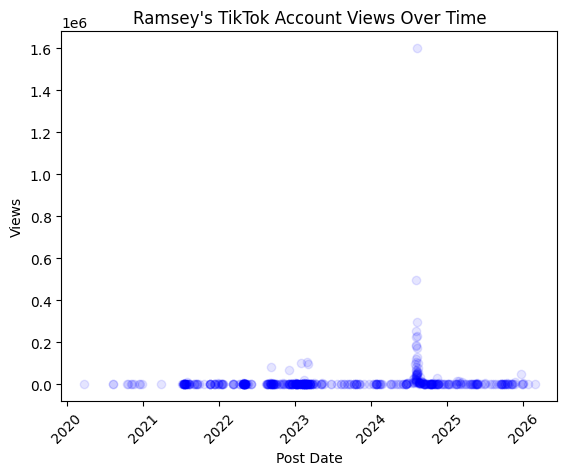

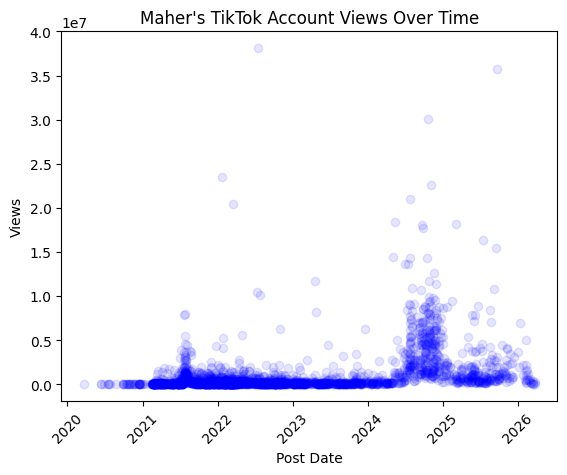

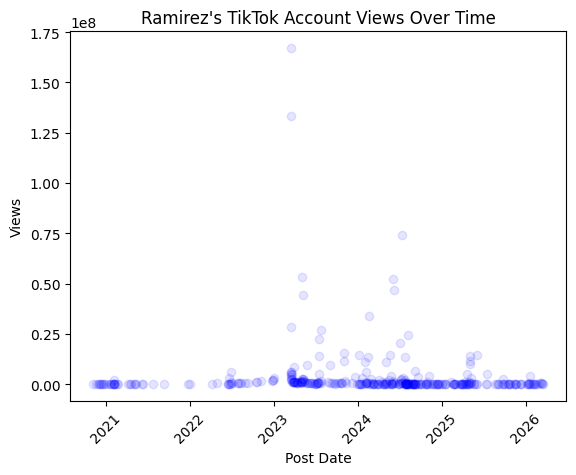

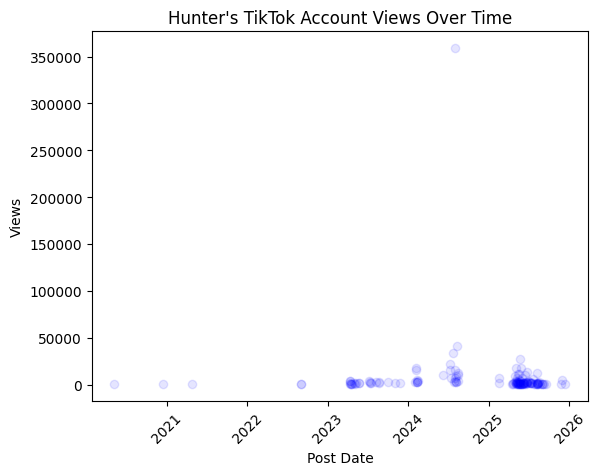

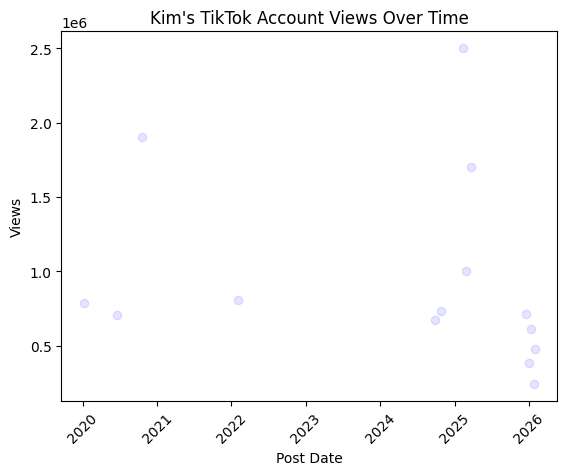

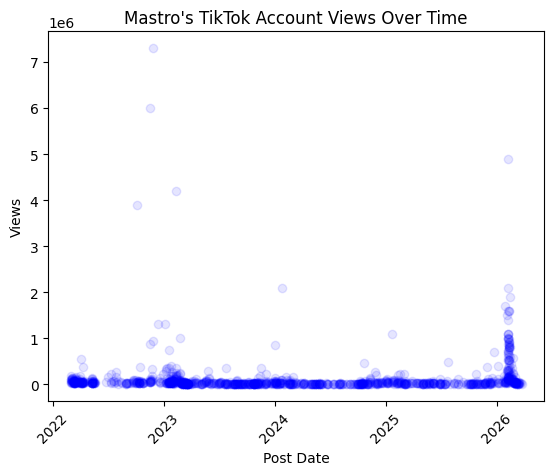

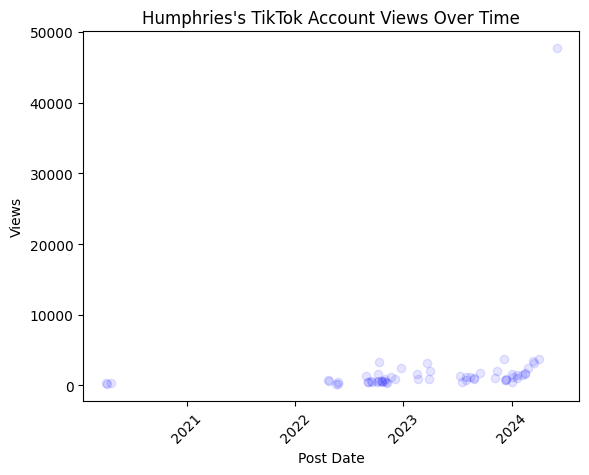

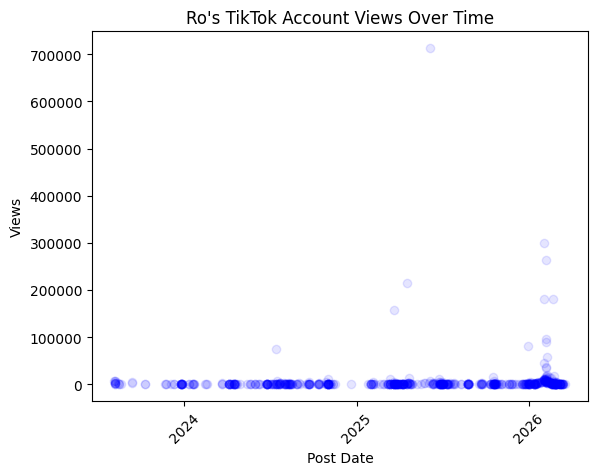

done


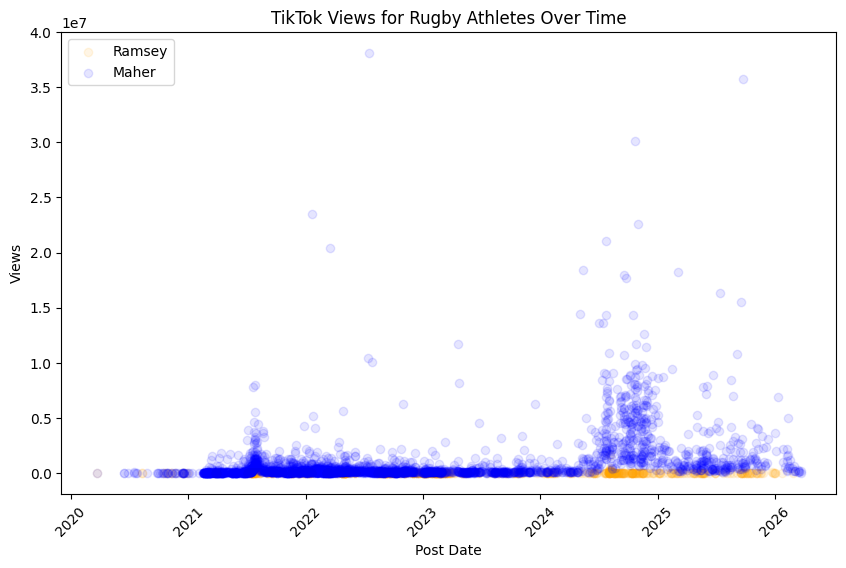

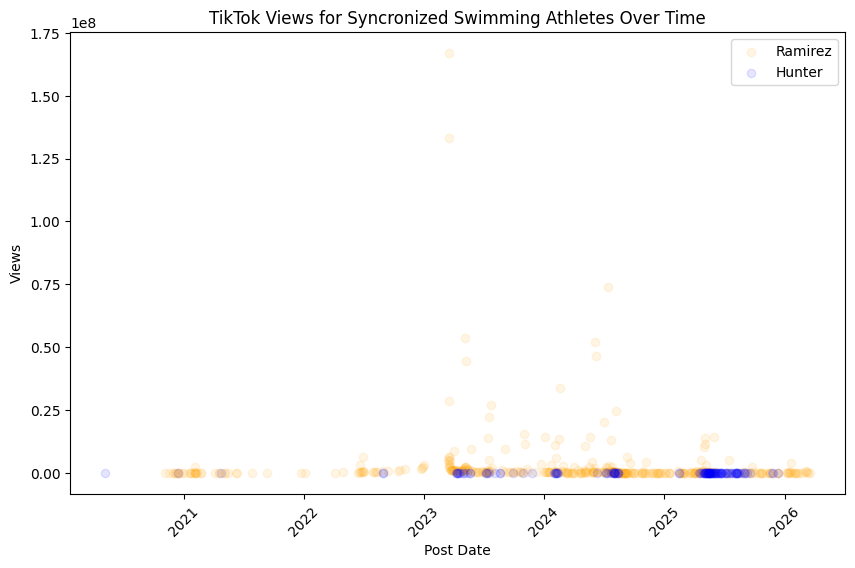

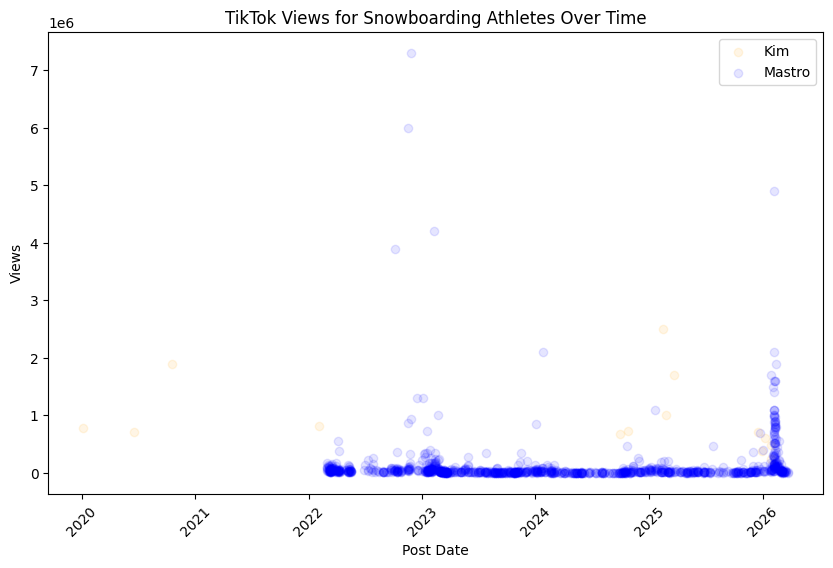

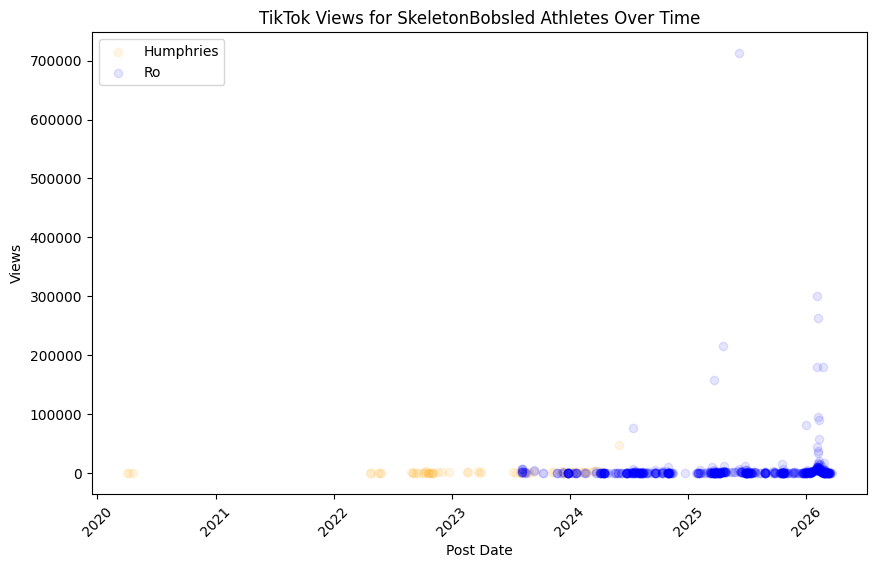

In [34]:
#individual scatter plots
for name, df in datasets.items():  
    df["Post Date"] = pd.to_datetime(df["Post Date"], errors="coerce")
    plt.figure()
    plt.scatter(df["Post Date"], df["Views"], color="blue", alpha=0.1)

    plt.title(f"{name}'s TikTok Account Views Over Time")
    plt.xlabel("Post Date")
    plt.ylabel("Views")
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.xticks(rotation=45)
    plt.show()


# scatter plot by sport
for athlete1, athlete2, sport in pairs:
    df1 = datasets[athlete1]
    df2 = datasets[athlete2]
    
    plt.figure(figsize=(10,6))
    plt.scatter(df1["Post Date"], df1["Views"], color="orange", alpha=0.1, label=athlete1)
    plt.scatter(df2["Post Date"], df2["Views"], color="blue", alpha=0.1, label=athlete2)

    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(f"TikTok Views for {sport} Athletes Over Time")
    plt.xlabel("Post Date")
    plt.ylabel("Views")
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    plt.legend()


# combined scatter plot (idk if to include this one or not)

# plt.figure()
# for name, df in datasets.items():
#     plt.scatter(df["Post Date"], df["Views"], label=name, alpha=.25)
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# plt.xlabel("Post Date")
# plt.ylabel("Views")
# plt.title("TikTok Views Over Time for All Athletes")
# plt.xticks(rotation=45)
# plt.legend()
# plt.tight_layout()
# plt.show()

print("done")

In [24]:
# summary stats for Google Trends of each sport
trends_stats = {}
for name, df in datasets_trends.items():
    stats = df["Total"].agg(["mean", "median", "std", "min", "max"])
    trends_stats[name] = stats
for name, stats in trends_stats.items():
    print(f"\n{name} Total Stats:\n", stats)


trend_yearly_stats = {}
for name, df in datasets_trends.items():
    df = df.copy()
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    df["Year"] = df["Time"].dt.year
    yearly = df.groupby("Year")["Total"].agg(["mean", "median", "std", "min", "max"])   # Group by year
    trend_yearly_stats[name] = yearly

print(trend_yearly_stats)


Rugby Total Stats:
 mean        6.344569
median      4.000000
std        15.850369
min         1.000000
max       231.000000
Name: Total, dtype: float64

Syncro Total Stats:
 mean        4.902622
median      2.000000
std        15.080170
min         1.000000
max       160.000000
Name: Total, dtype: float64

Snowboarding Total Stats:
 mean        5.471910
median      3.000000
std        24.698067
min         0.000000
max       402.000000
Name: Total, dtype: float64

Skeleton\Bobsled Total Stats:
 mean        4.951311
median      0.000000
std        37.718704
min         0.000000
max       390.000000
Name: Total, dtype: float64
{'Rugby':            mean  median        std  min  max
Year                                        
2004   5.500000     5.0   1.445998    4    8
2005   4.250000     4.0   1.356801    2    6
2006   4.333333     4.0   1.922751    1    9
2007   3.750000     3.0   1.356801    2    7
2008   3.333333     3.0   1.073087    2    5
2009   3.166667     3.0   1.114641    1 

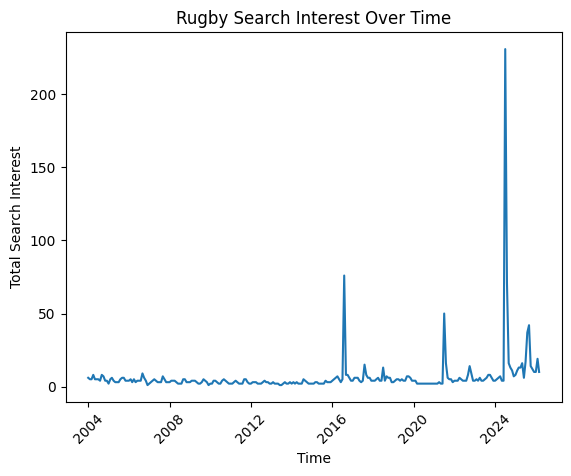

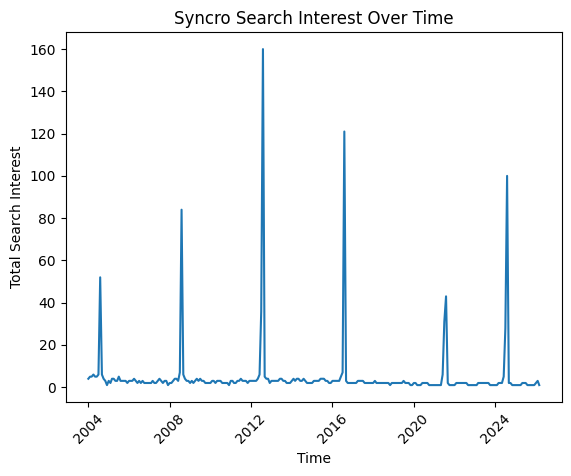

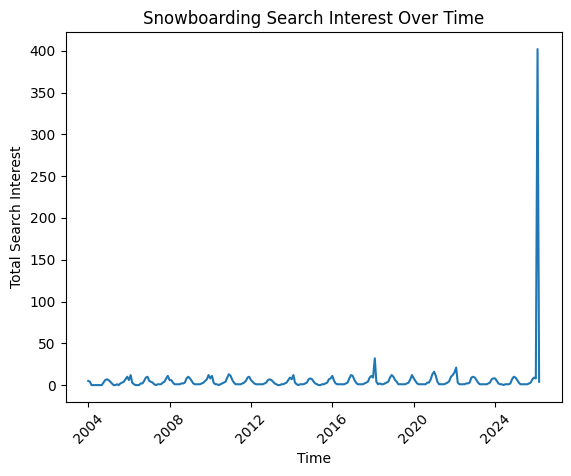

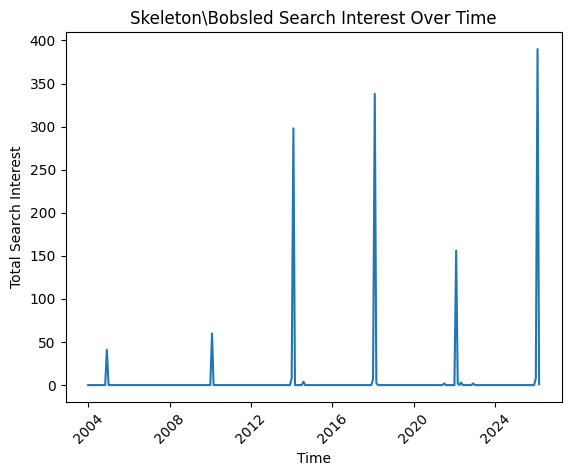

In [30]:
for name, df in datasets_trends.items():
    df = df.copy()
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    
    plt.figure()
    plt.plot(df["Time"], df["Total"])
    
    plt.title(f"{name} Search Interest Over Time")
    plt.xlabel("Time")
    plt.ylabel("Total Search Interest")
    
    plt.xticks(rotation=45)
    plt.show()

In [62]:
# correlation analysis by month
correlation_results = {}
for name1, name2, sport in pairs:
    df1 = datasets[name1].copy()
    df2 = datasets[name2].copy()
    trends = datasets_trends[sport].copy()
    
    # data for athletes
    for df in [df1, df2]:
        df["Post Date"] = pd.to_datetime(df["Post Date"], errors="coerce")
    tiktok = pd.concat([df1, df2], ignore_index=True)
    
    # monthly aggregation
    tiktok["Month"] = tiktok["Post Date"].dt.to_period("M")
    tiktok_monthly = tiktok.groupby("Month")["Views"].sum().reset_index()
    
    # trends data
    trends["Time"] = pd.to_datetime(trends["Time"], errors="coerce")
    trends["Month"] = trends["Time"].dt.to_period("M")
    
    trends_monthly = trends.groupby("Month")["Total"].mean().reset_index()
    
    # megre by month
    merged = pd.merge(tiktok_monthly, trends_monthly, on="Month", how="inner")
    if len(merged) > 2:
        merged["Views_norm"] = (merged["Views"] - merged["Views"].mean()) / merged["Views"].std()
        merged["Total_norm"] = (merged["Total"] - merged["Total"].mean()) / merged["Total"].std()
        corr = merged["Views_norm"].corr(merged["Total_norm"])
    else:
        corr = np.nan
    
    correlation_results[sport] = corr

for sport, corr in correlation_results.items():
    print(f"{sport} Trend Correlation: {corr:.3f}")

Rugby Trend Correlation: 0.443
Syncro Trend Correlation: 0.080
Snowboarding Trend Correlation: 0.937
SkeletonBobsled Trend Correlation: 0.899


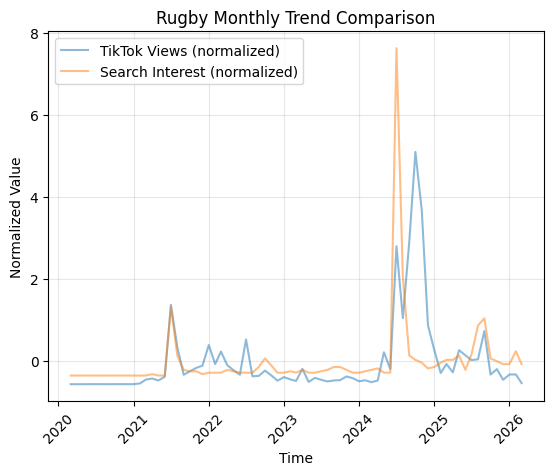

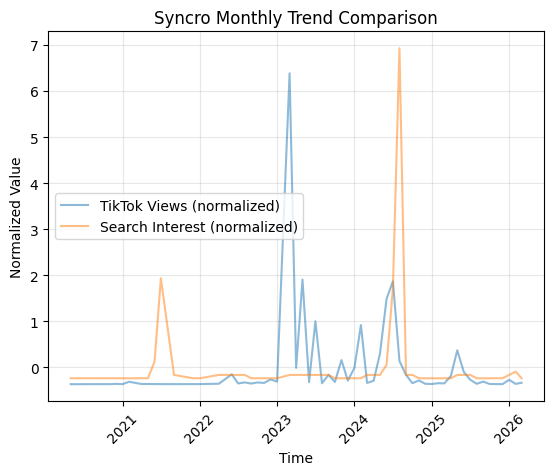

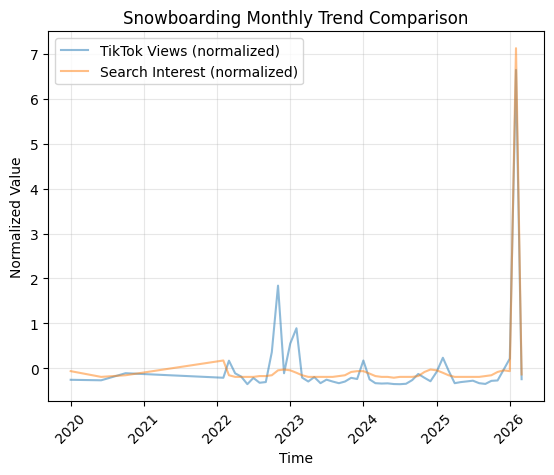

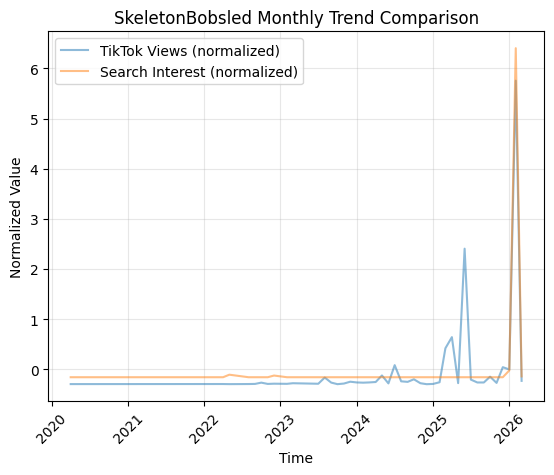

In [50]:
# correlation visualization 
import matplotlib.pyplot as plt

for name1, name2, sport in pairs:
    df1 = datasets[name1].copy()
    df2 = datasets[name2].copy()
    trends = datasets_trends[sport].copy()
    for df in [df1, df2]:
        df["Post Date"] = pd.to_datetime(df["Post Date"], errors="coerce")
    tiktok = pd.concat([df1, df2])
    tiktok["Month"] = tiktok["Post Date"].dt.to_period("M")
    tiktok_monthly = tiktok.groupby("Month")["Views"].sum().reset_index()
    trends["Time"] = pd.to_datetime(trends["Time"], errors="coerce")
    trends["Month"] = trends["Time"].dt.to_period("M")
    trends_monthly = trends.groupby("Month")["Total"].mean().reset_index()
    merged = pd.merge(tiktok_monthly, trends_monthly, on="Month", how="inner")
    
    # convert Month → datetime for plotting
    merged["Month"] = merged["Month"].dt.to_timestamp()
    
    # normalize
    merged["Views_norm"] = (merged["Views"] - merged["Views"].mean()) / merged["Views"].std()
    merged["Total_norm"] = (merged["Total"] - merged["Total"].mean()) / merged["Total"].std()
    
    plt.figure()
    plt.plot(merged["Month"], merged["Views_norm"], label="TikTok Views (normalized)", alpha=.5)
    plt.plot(merged["Month"], merged["Total_norm"], label="Search Interest (normalized)", alpha=.5)
    plt.title(f"{sport} Monthly Trend Comparison")
    plt.xlabel("Time")
    plt.ylabel("Normalized Value")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [64]:
# correlation analysis by year
correlation_results = {}
for name1, name2, sport in pairs:
    df1 = datasets[name1].copy()
    df2 = datasets[name2].copy()
    trends = datasets_trends[sport].copy()
    
    # data for athletes
    for df in [df1, df2]:
        df["Post Date"] = pd.to_datetime(df["Post Date"], errors="coerce")
    tiktok = pd.concat([df1, df2], ignore_index=True)
    
    # monthly aggregation
    tiktok["Year"] = tiktok["Post Date"].dt.to_period("Y")
    tiktok_monthly = tiktok.groupby("Year")["Views"].sum().reset_index()
    
    # trends data
    trends["Time"] = pd.to_datetime(trends["Time"], errors="coerce")
    trends["Year"] = trends["Time"].dt.to_period("Y")
    
    trends_monthly = trends.groupby("Year")["Total"].mean().reset_index()
    
    # megre by month
    merged = pd.merge(tiktok_monthly, trends_monthly, on="Year", how="inner")
    if len(merged) > 2:
        merged["Views_norm"] = (merged["Views"] - merged["Views"].mean()) / merged["Views"].std()
        merged["Total_norm"] = (merged["Total"] - merged["Total"].mean()) / merged["Total"].std()
        corr = merged["Views_norm"].corr(merged["Total_norm"])
    else:
        corr = np.nan
    
    correlation_results[sport] = corr

for sport, corr in correlation_results.items():
    print(f"{sport} Trend Correlation: {corr:.3f}")

Rugby Trend Correlation: 0.896
Syncro Trend Correlation: 0.234
Snowboarding Trend Correlation: 0.848
SkeletonBobsled Trend Correlation: 0.708


In [72]:
# Correlation by month (excluding olympic games months)

# set dates
olympic_dates = {
    "Summer": [
        ("2021-07-23", "2021-08-08"),
        ("2024-07-26", "2024-08-11")
    ],
    "Winter": [
        ("2022-02-02", "2022-02-20"),
        ("2026-02-06", "2026-02-22")
    ]
}
olympic_months = {"Summer": set(), "Winter": set()}

for season, ranges in olympic_dates.items():
    for start, end in ranges:
        start = pd.to_datetime(start)
        end = pd.to_datetime(end)
        months = pd.period_range(start=start, end=end, freq="M")
        olympic_months[season].update(months)


correlation_results = {}
for name1, name2, sport, season in pairs:
    df1 = datasets[name1].copy()
    df2 = datasets[name2].copy()
    trends = datasets_trends[sport].copy()
    
    # account data
    for df in [df1, df2]:
        df["Post Date"] = pd.to_datetime(df["Post Date"], errors="coerce")
    
    tiktok = pd.concat([df1, df2], ignore_index=True)
    tiktok["Month"] = tiktok["Post Date"].dt.to_period("M")
    
    # remove olympic months
    tiktok = tiktok[~tiktok["Month"].isin(olympic_months[season])]
    
    tiktok_monthly = tiktok.groupby("Month")["Views"].sum().reset_index()
    
    # google data
    trends["Time"] = pd.to_datetime(trends["Time"], errors="coerce")
    trends["Month"] = trends["Time"].dt.to_period("M")
    
    # remove olympic months
    trends = trends[~trends["Month"].isin(olympic_months[season])]
    
    trends_monthly = trends.groupby("Month")["Total"].mean().reset_index()
    
    merged = pd.merge(tiktok_monthly, trends_monthly, on="Month", how="inner")
    if len(merged) > 2:
        merged["Views_norm"] = (merged["Views"] - merged["Views"].mean()) / merged["Views"].std()
        merged["Total_norm"] = (merged["Total"] - merged["Total"].mean()) / merged["Total"].std()
        corr = merged["Views_norm"].corr(merged["Total_norm"])
    else:
        corr = np.nan
    correlation_results[sport] = corr

for sport, corr in correlation_results.items():
    print(f"{sport} Trend Correlation (No Olympics): {corr:.3f}")

Rugby Trend Correlation (No Olympics): 0.308
Syncro Trend Correlation (No Olympics): 0.203
Snowboarding Trend Correlation (No Olympics): 0.480
SkeletonBobsled Trend Correlation (No Olympics): 0.008


In [79]:
# Correlation by year (excluding olympic games years)
olympic_years = {
    "Summer": {2021, 2024},
    "Winter": {2022, 2026}
}

correlation_results = {}
for name1, name2, sport, season in pairs:
    df1 = datasets[name1].copy()
    df2 = datasets[name2].copy()
    trends = datasets_trends[sport].copy()
    
    # account data
    for df in [df1, df2]:
        df["Post Date"] = pd.to_datetime(df["Post Date"], errors="coerce")
    
    tiktok = pd.concat([df1, df2], ignore_index=True)
    tiktok["Year"] = tiktok["Post Date"].dt.year
    
    # remove olympic years
    tiktok = tiktok[~tiktok["Year"].isin(olympic_years[season])]
    
    tiktok_yearly = tiktok.groupby("Year")["Views"].sum().reset_index()
    
    # google data
    trends["Time"] = pd.to_datetime(trends["Time"], errors="coerce")
    trends["Year"] = trends["Time"].dt.year
    
    # remove olympic years
    trends = trends[~trends["Year"].isin(olympic_years[season])]
    
    trends_yearly = trends.groupby("Year")["Total"].mean().reset_index()
    
    merged = pd.merge(tiktok_yearly, trends_yearly, on="Year", how="inner")
    if len(merged) > 2:
        merged["Views_norm"] = (merged["Views"] - merged["Views"].mean()) / merged["Views"].std()
        merged["Total_norm"] = (merged["Total"] - merged["Total"].mean()) / merged["Total"].std()
        corr = merged["Views_norm"].corr(merged["Total_norm"])
    else:
        corr = np.nan
    correlation_results[sport] = corr

for sport, corr in correlation_results.items():
    print(f"{sport} Trend Correlation (No Olympic Years): {corr:.3f}")

Rugby Trend Correlation (No Olympic Years): 0.486
Syncro Trend Correlation (No Olympic Years): -0.075
Snowboarding Trend Correlation (No Olympic Years): -0.193
SkeletonBobsled Trend Correlation (No Olympic Years): nan


In [81]:
# OLD retention analysis

# exact dates
# # summer 2021 dates
# olympic_start = pd.to_datetime("2021-07-23")
# olympic_end = pd.to_datetime("2021-08-08")

# # winter 2022 dates
# olympic_start = pd.to_datetime("2022-02-02")
# olympic_end = pd.to_datetime("2022-02-20")

# # summer 2024 dates
# olympic_start = pd.to_datetime("2024-07-26")
# olympic_end = pd.to_datetime("2024-08-11")

# # winter 2026 dates
# olympic_start = pd.to_datetime("2026-02-06")
# olympic_end = pd.to_datetime("2026-02-22")


# dates with month-long buffers
# # summer 2021 dates
# olympic_start = pd.to_datetime("2021-06-23")
# olympic_end = pd.to_datetime("2021-09-08")

# # winter 2022 dates
# olympic_start = pd.to_datetime("2022-01-02")
# olympic_end = pd.to_datetime("2022-03-20")

# # summer 2024 dates
# olympic_start = pd.to_datetime("2024-06-26")
# olympic_end = pd.to_datetime("2024-09-11")

# # winter 2026 dates
# olympic_start = pd.to_datetime("2026-01-06")
# olympic_end = pd.to_datetime("2026-03-22")

# standardizing the period before and after a game we are looking at -> currently set to 3 years before and after
pre_start = olympic_start - pd.DateOffset(years=3)
post_end = olympic_end + pd.DateOffset(years=3)

retention_results = {}
for sport, df in datasets_trends.items():
    df = df.copy()
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    
    # restrict to relevant window only
    df = df[(df["Time"] >= pre_start) & (df["Time"] <= post_end)]
    
    # define periods
    pre = df[(df["Time"] >= pre_start) & (df["Time"] < olympic_start)]
    during = df[(df["Time"] >= olympic_start) & (df["Time"] <= olympic_end)]
    post = df[(df["Time"] > olympic_end) & (df["Time"] <= post_end)]
    
    stats = {
        "pre_avg": pre["Total"].mean(),
        "during_avg": during["Total"].mean(),
        "post_avg": post["Total"].mean(),
        "pre_median": pre["Total"].median(),
        "during_median": during["Total"].median(),
        "post_median": post["Total"].median(),
    }
    
    # percent change
    stats["post_vs_pre_%"] = (
        (stats["post_avg"] - stats["pre_avg"]) / stats["pre_avg"]
    ) * 100
    
    retention_results[sport] = stats

for sport, stats in retention_results.items():
    print(f"\n{sport}")
    for k, v in stats.items():
        print(f"{k}: {v:.2f}")


Rugby
pre_avg: 18.39
during_avg: nan
post_avg: 10.00
pre_median: 8.00
during_median: nan
post_median: 10.00
post_vs_pre_%: -45.62

Syncro
pre_avg: 5.11
during_avg: nan
post_avg: 1.00
pre_median: 2.00
during_median: nan
post_median: 1.00
post_vs_pre_%: -80.43

Snowboarding
pre_avg: 14.47
during_avg: nan
post_avg: 4.00
pre_median: 2.00
during_median: nan
post_median: 4.00
post_vs_pre_%: -72.36

SkeletonBobsled
pre_avg: 11.06
during_avg: nan
post_avg: 1.00
pre_median: 0.00
during_median: nan
post_median: 1.00
post_vs_pre_%: -90.95


In [84]:
# Retention Calculation
olympic_dates = {
    "Summer": [
        ("2021-07-23", "2021-08-08"),
        ("2024-07-26", "2024-08-11")
    ],
    "Winter": [
        ("2022-02-02", "2022-02-20"),
        ("2026-02-06", "2026-02-22")
    ]
}

sport_season = {sport: season for _, _, sport, season in pairs}
retention_results = {}
for sport, df in datasets_trends.items():
    df = df.copy()
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    season = sport_season[sport]
    retention_results[sport] = []
    
    for start_str, end_str in olympic_dates[season]:
        olympic_start = pd.to_datetime(start_str)
        olympic_end = pd.to_datetime(end_str)
        
        pre_start = olympic_start - pd.DateOffset(years=3)
        post_end = olympic_end + pd.DateOffset(years=3)
        
        # restrict window -> 3 years before and after
        df_window = df[(df["Time"] >= pre_start) & (df["Time"] <= post_end)].copy()
        
        df_window["Month"] = df_window["Time"].dt.to_period("M")
        olympic_start_month = olympic_start.to_period("M")
        olympic_end_month = olympic_end.to_period("M")
        
        pre = df_window[df_window["Month"] < olympic_start_month]
        during = df_window[(df_window["Month"] >= olympic_start_month) & (df_window["Month"] <= olympic_end_month)]
        post = df_window[df_window["Month"] > olympic_end_month]
        
        stats = {
            "olympic_start": olympic_start,
            "olympic_end": olympic_end,
            "pre_avg": pre["Total"].mean(),
            "during_avg": during["Total"].mean(),
            "post_avg": post["Total"].mean(),
            "pre_median": pre["Total"].median(),
            "during_median": during["Total"].median(),
            "post_median": post["Total"].median(),
        }
        
        if stats["pre_avg"] != 0:
            stats["post_vs_pre_%"] = ((stats["post_avg"] - stats["pre_avg"]) / stats["pre_avg"]) * 100
        else:
            stats["post_vs_pre_%"] = np.nan
        
        retention_results[sport].append(stats)

for sport, events in retention_results.items():
    print(f"{sport}")
    for stats in events:
        print(f"Olympics: {stats['olympic_start'].date()} to {stats['olympic_end'].date()}")
        for k, v in stats.items():
            if k not in ["olympic_start", "olympic_end"]:
                print(f"{k}: {v:.2f}")
        print()

Rugby
Olympics: 2021-07-23 to 2021-08-08
pre_avg: 3.57
during_avg: 33.00
post_avg: 13.47
pre_median: 3.00
during_median: 33.00
post_median: 5.00
post_vs_pre_%: 277.22

Olympics: 2024-07-26 to 2024-08-11
pre_avg: 5.69
during_avg: 151.00
post_avg: 15.00
pre_median: 5.00
during_median: 151.00
post_median: 13.00
post_vs_pre_%: 163.82

Syncro
Olympics: 2021-07-23 to 2021-08-08
pre_avg: 1.74
during_avg: 37.00
post_avg: 5.11
pre_median: 2.00
during_median: 37.00
post_median: 2.00
post_vs_pre_%: 193.26

Olympics: 2024-07-26 to 2024-08-11
pre_avg: 2.83
during_avg: 64.00
post_avg: 1.42
pre_median: 2.00
during_median: 64.00
post_median: 1.00
post_vs_pre_%: -49.76

Snowboarding
Olympics: 2022-02-02 to 2022-02-20
pre_avg: 4.60
during_avg: 21.00
post_avg: 3.61
pre_median: 3.00
during_median: 21.00
post_median: 2.00
post_vs_pre_%: -21.50

Olympics: 2026-02-06 to 2026-02-22
pre_avg: 3.40
during_avg: 402.00
post_avg: 4.00
pre_median: 2.00
during_median: 402.00
post_median: 4.00
post_vs_pre_%: 17.65

Sk

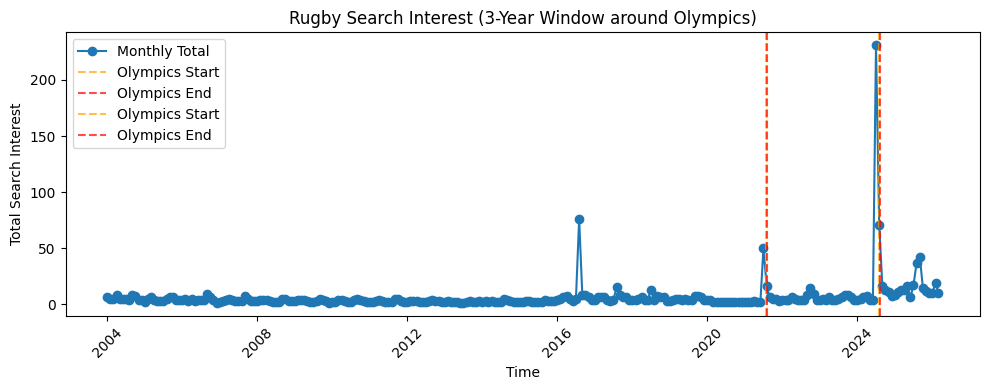

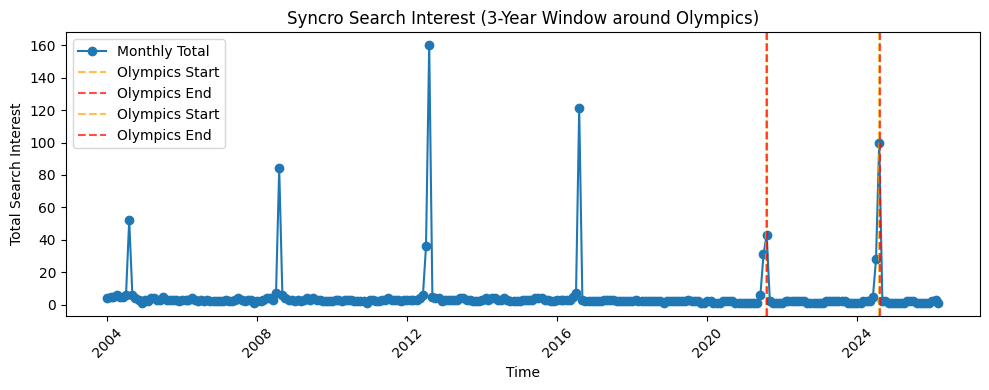

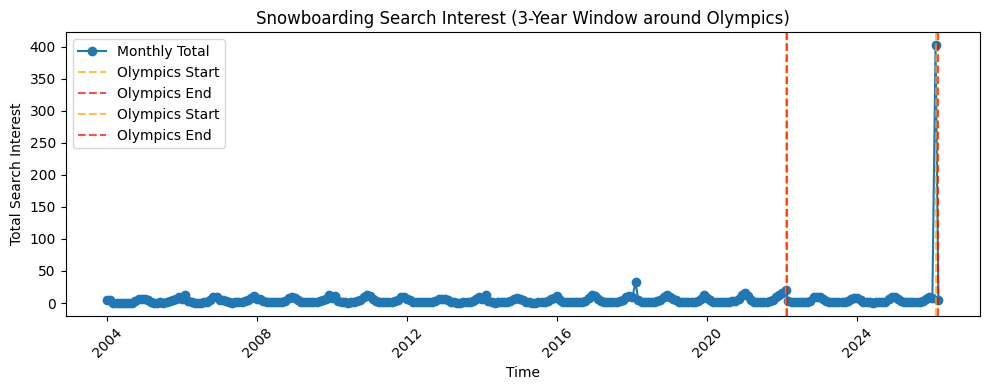

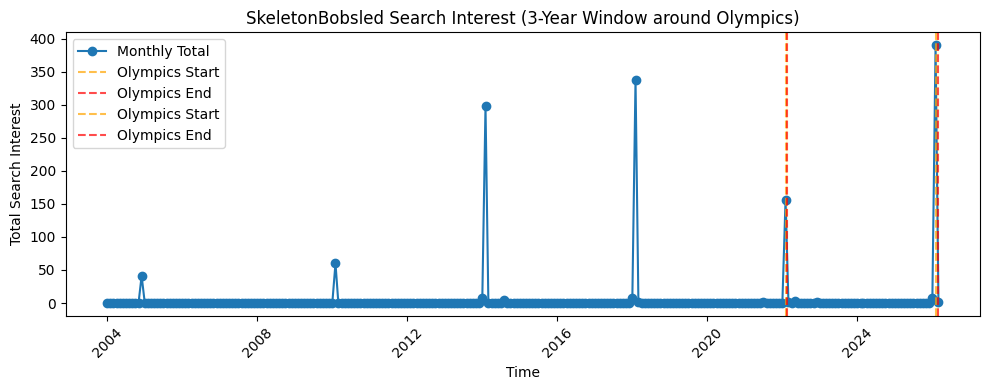

In [88]:
# retention visualization 
for sport, df in datasets_trends.items():
    df = df.copy()
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    df = df.sort_values("Time")
    season = sport_season[sport]
    
    plt.figure(figsize=(10, 4))
    plt.plot(df["Time"], df["Total"], marker='o', label="Monthly Total")
    
    for start_str, end_str in olympic_dates[season]:
        olympic_start = pd.to_datetime(start_str)
        olympic_end = pd.to_datetime(end_str)
        
        plt.axvline(olympic_start, linestyle="--", color="orange", alpha=0.7, label="Olympics Start")
        plt.axvline(olympic_end, linestyle="--", color="red", alpha=0.7, label="Olympics End")
        plt.axvspan(olympic_start, olympic_end, color="yellow", alpha=0.1)
    
    plt.title(f"{sport} Search Interest (3-Year Window around Olympics)")
    plt.xlabel("Time")
    plt.ylabel("Total Search Interest")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
    